# Introduction

This is a preliminary tutorial for the preliminary release of the SBI MRI package. Please do not use it for any official purposes yet, as it still needs to be validated. However, several quality of life improvements are there that you can use to speed up current implementations.

Importantly the package is split into two fundamental parts:
 - the models file
 - the SBI file

The models file is where most of the new stuff is - so I would be quite careful there. The SBI part is relatively standard, including on GPU speed up etc. So if you want to use one part of this package please start with that first.

# Models

In [88]:
from Models import *


%load_ext autoreload

%autoreload 2

from dipy.data import get_fnames
from dipy.core.gradients import gradient_table
from dipy.io.gradients import read_bvals_bvecs
from dipy.core.sphere import disperse_charges, Sphere, HemiSphere
from dipy.io.image import load_nifti

import requests
from pathlib import Path
import zipfile
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This part of the package was built to allow for modular construction of dwMRI models. It means you instantiate a model and then you can add compartments to it as you see fit. Lets start by defining a random gradient table. This is taking directly from dipy and is a overview of your acquisition. If you are working multi diffusion time it is quite important to have that in there as follows:

In [89]:
 # Just an example set 
fimg_init, fbvals, fbvecs = get_fnames(name='small_64D')
bvals, bvecs = read_bvals_bvecs(fbvals, fbvecs) 
hsph_initial = HemiSphere(xyz=bvecs[1:])
hsph_updated,_ = disperse_charges(hsph_initial,5000)
bvecs = np.vstack([[0,0,0],hsph_updated.vertices])
bvalsExt = np.hstack([bvals, 3000*np.ones_like(bvals)])
bvecsExt = np.vstack([bvecs, bvecs])
bvalsExt[65] = 0

In [90]:
gtabSim = gradient_table(bvals=bvalsExt, bvecs=bvecsExt,small_delta = 0.007*np.ones_like(bvalsExt), big_delta = 0.0173*np.ones_like(bvalsExt))

Note please the: ```small_delta = 0.007*np.ones_like(bvalsExt), big_delta = 0.0173*np.ones_like(bvalsExt)```
Here we have all the same $\delta$ and $\Delta$, but if you have changing deltas please make sure this is reflected in the vector.

Then we can define a model as follows

In [91]:
DTIModel = Model(gtabSim)
DTIModel._add_compartment("DTI","Hindered") # The first "DTI" is what kind of model we want and "Hindered" is the name we give it
DTIModel._set_default_SNR(20)

# or

AxCaliberModel = Model(gtabSim)
AxCaliberModel._add_compartment("DTI","Hindered")
AxCaliberModel._add_compartment("Sticks","Axons",Size='Infer')
AxCaliberModel._add_compartment("Sticks","Dendrites",Dispersion=True,Size='Infer')
AxCaliberModel._set_default_SNR(50)

# or

StickAndBallModel = Model(gtabSim)
StickAndBallModel._add_compartment("DTI","Hindered")
StickAndBallModel._add_compartment("Sticks","Axons",Size='Infer')
StickAndBallModel._add_compartment("Balls","Astrocytes")
StickAndBallModel._set_default_SNR(50)

# or 

StickAndBallFWModel = Model(gtabSim)
StickAndBallFWModel._add_compartment("DTI","Hindered")
StickAndBallFWModel._add_compartment("Sticks","Axons",Size='Infer')
StickAndBallFWModel._add_compartment("Balls","Astrocytes")
StickAndBallFWModel._add_compartment("FreeWater","Free Water")
StickAndBallFWModel._set_default_SNR(50)

*****WARNING: You are trying to fit size with only 1 diffusion time - proceed with caution!*****
*****WARNING: You are trying to fit size with only 1 diffusion time - proceed with caution!*****
*****WARNING: You are trying to fit size with only 1 diffusion time - proceed with caution!*****
*****WARNING: You are trying to fit size with only 1 diffusion time - proceed with caution!*****
*****WARNING: You are trying to fit size with only 1 diffusion time - proceed with caution!*****
*****WARNING: You are trying to fit size with only 1 diffusion time - proceed with caution!*****


All of the compartments have slightly arguments. If you want to figure out what these are you can do:

In [92]:
help(Sticks)

Help on class Sticks in module Models:

class Sticks(Compartment)
 |  Sticks(
 |      gtab,
 |      D_par_min=0,
 |      D_par_max=0.005,
 |      D_perp_min=0,
 |      D_perp_max=0.005,
 |      Dispersion=False,
 |      kappa_min=0,
 |      kappa_max=10,
 |      Size='Infer',
 |      size_min=0.0001,
 |      size_max=0.005
 |  )
 |
 |  Restricted anisotropic diffusion compartment with optional orientation
 |  dispersion and axon-size modelling.
 |
 |  The compartment models diffusion using an oriented cylindrical geometry
 |  with separate parallel and perpendicular diffusivities. Fibre orientation
 |  is parameterized by spherical angles. Optional Watson orientation
 |  dispersion and several radius models are supported.
 |
 |  Parameters
 |  ----------
 |  gtab : object
 |      Gradient table containing gradient directions, b-values, and diffusion
 |      timing information.
 |
 |  D_par_min : float, optional
 |      Minimum parallel diffusivity used for sampling. Default is 0.
 |
 |

If you then want simulate these models its as easy as:

In [93]:
Params,Signals = StickAndBallFWModel.sample_and_simulation(10_000,parallel=True)

Simulating Free Water: : 4it [00:27,  6.78s/it]


Conveniently, the models build your parameter list dynamically and can be accessed as:

In [94]:
StickAndBallFWModel._get_parameter_names

['Hindered_f',
 'Axons_f',
 'Astrocytes_f',
 'Free Water_f',
 'Hindered_D_xx',
 'Hindered_D_xy',
 'Hindered_D_yy',
 'Hindered_D_xz',
 'Hindered_D_yz',
 'Hindered_D_zz',
 'Axons_theta',
 'Axons_phi',
 'Axons_D_par',
 'Axons_D_perp',
 'Axons_size',
 'Astrocytes_D_sph',
 'Astrocytes_size']

For memory purposes its best to always use parallel = True - but currently the n_jobs is set to -1. So if you want to run on the cluster and dont mind waiting a bit you can set parallel to False.

Now you might have noticed that a file was saved - this is saved as DSBFW_todaysdat_timenow.h5. The DSBFW describes the model you are running and changes based on the compartments you have: 
- D = DTI
- S = Sticks
- B = Balls
- FW = Freewater

This way you can generate simulations and they will be automatically saved for reuse. If you want to add a random seed, its as simple as  

In [95]:
Params,Signals = StickAndBallFWModel.sample_and_simulation(10_000,parallel=True,save=True,rng = np.random.default_rng(42))

Simulating Free Water: : 4it [00:18,  4.72s/it]

File was saved as saved_data/DSBFW_20260821_1143.h5!


By accident, we now overwrote the previous simulations - if we want to get them back there is a useful little function:

In [96]:
P,S,S_raw,names,snr = Helpers.read_h5('saved_data/DSBFW_20260821_1104.h5') #(put the name of the file from before

Also right now the snr is set to a default 50 for the model (._set_default_SNR(50)). 
if you want to change it just put in: 

In [97]:
Params,Signals = StickAndBallFWModel.sample_and_simulation(10_000,parallel=True,rng = np.random.default_rng(42),custom_snr=30)

Simulating Free Water: : 4it [00:19,  4.93s/it]


# SBI

The SBI part will be something all of you are more familiar with. All i have done is put things in one place and sped some other things up. So how does this work in our current set-up.

We have generated some parameters and associated signals S. First we need to make sure that our data is in the right format, and that we don't include redundant information

In [98]:
import Helpers #Custom functions
import SBI

In [99]:
Par,Obs,Names,Bounds = Helpers.Prep_data(P,S,names)

As one of the fractions is redundant we will remove it (1-sum of the rest). We are removing: Hindered_f


Next we train the network

In [100]:
Helpers.make_data_folder('test')

PosixPath('saved_data/test')

In [101]:
Network = SBI.Train_Network_gpu(Par,Obs) #this will automatically see if you have speed-up possibilities (either GPU or mac MPS)

/Users/maximilianeggl/miniconda3/envs/SBIPackage/lib/python3.14/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(
/Users/maximilianeggl/miniconda3/envs/SBIPackage/lib/python3.14/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Parameters theta has device 'cpu'. Moving theta to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(


 Neural network successfully converged after 126 epochs.Network saved as 'saved_data/Network_10k_20260821_1144.pickle'


/Users/maximilianeggl/miniconda3/envs/SBIPackage/lib/python3.14/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


Lets say now we want to do some inference on an in-silico dataset

In [102]:
Params_test,Signals_test = StickAndBallFWModel.sample_and_simulation(500,parallel=True,rng = np.random.default_rng(2026),custom_snr=30)

Simulating Free Water: : 4it [00:02,  1.73it/s]


In [103]:
Par_t,Obs_t,_,_ = Helpers.Prep_data(Params_test,Signals_test,StickAndBallFWModel._get_parameter_names)

As one of the fractions is redundant we will remove it (1-sum of the rest). We are removing: Hindered_f


In [104]:
Result = SBI.Infer(Network,Obs_t)

  0%|                                                   | 0/16 [00:00<?, ?it/s]/Users/maximilianeggl/Dropbox/PostDoc/Projects/SBIPackage/SBI_MRI/SBI.py:185: UserWarning: Capping max_sampling_batch_size from 10000 to 3125 to avoid excessive memory usage.
  s = Network.sample_batched((samples,), O_batch,show_progress_bars=False)
 94%|███████████████████████████████████████▍  | 15/16 [00:00<00:00, 19.72it/s]/Users/maximilianeggl/Dropbox/PostDoc/Projects/SBIPackage/SBI_MRI/SBI.py:185: UserWarning: Capping max_sampling_batch_size from 10000 to 5000 to avoid excessive memory usage.
  s = Network.sample_batched((samples,), O_batch,show_progress_bars=False)
100%|██████████████████████████████████████████| 16/16 [00:00<00:00, 19.50it/s]


We can also run this over a whole Volume using ```InferFromVolume()```. Here the input is the network, the data (can be 2D or 3D) and an associated Mask. Depending on the size of the data you are passing this might take a bit.

# Example of in-vivo

Now lets run an in-vivo example - this data includes multiple b-values and diffusion times, so it is suitable for both DTI and more advanced multi-compartment models.

In [105]:
def download_dropbox(url, output_path):
    # Force Dropbox to return the file rather than the preview page
    if "dl=0" in url:
        url = url.replace("dl=0", "dl=1")
    elif "dl=1" not in url:
        url += "&dl=1" if "?" in url else "?dl=1"

    output_path = Path(output_path)

    with requests.get(url, stream=True) as r:
        r.raise_for_status()

        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    return output_path

First we make sure to download the data and unzip the file into ./dat.

In [106]:
url = "https://www.dropbox.com/scl/fi/xki53zdriavev4rt22wjz/data.zip?rlkey=ejfw5malh99l98sv747jg273c&dl=1"
download_dropbox(url, "data3.zip")
with zipfile.ZipFile("data3.zip", "r") as z:
    z.extractall("./dat")

In [107]:
fdwi = './dat/output.nii.gz'
bvaloc = './dat/bvals.bvals'
bveloc = './dat/bvecs.bvecs'
deltas = './dat/deltas.deltas'
data, affine, img = load_nifti(fdwi, return_img=True)
bvals = np.loadtxt(bvaloc)
bvecs = np.loadtxt(bveloc)
deltas = np.loadtxt(deltas)

Now importantly, this data is *NOT* normalised - however the implementation assumes it is. Therefore, it is key that you make sure that you divide by teh average of the $b_0$ - if you only have one, just divide by that one.

In [108]:
data_norm = data/data[...,bvals==0].mean(axis=-1)[...,None]

/var/folders/nz/zgf8q4hn5qs6xlrf_05cpv_m0000gn/T/ipykernel_60964/1322647217.py:1: RuntimeWarning: invalid value encountered in divide
  data_norm = data/data[...,bvals==0].mean(axis=-1)[...,None]


Lets define a model with the correct gradient table:

In [109]:
gtab = gradient_table(bvals=bvals, bvecs=bvecs,small_delta = 0.007*np.ones_like(bvals), big_delta = deltas*1e-3)

First, lets just start with a DTI model - keeping in mind that multiple b-values and Deltas are not really optimal for DTI:

In [110]:
DTIModel = Model(gtab)
DTIModel._add_compartment("DTI","DTI")
DTIModel._set_default_SNR(50)

In [111]:
Params,Signals = DTIModel.sample_and_simulation(10_000,parallel=True,rng = np.random.default_rng(42))
Par,Obs,Names,Bounds = Helpers.Prep_data(Params,Signals,DTIModel.parameter_list)

Simulating DTI: : 1it [00:00,  2.00it/s]

As one of the fractions is redundant we will remove it (1-sum of the rest). We are removing: DTI_f


In [112]:
DTINetwork = SBI.Train_Network_gpu(Par,Obs) #this will automatically see if you have speed-up possibilities (either GPU or mac MPS)

/Users/maximilianeggl/miniconda3/envs/SBIPackage/lib/python3.14/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 241, 242, 243, 244, 245, 246, 247, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 27

 Neural network successfully converged after 97 epochs.Network saved as 'saved_data/Network_10k_20260821_1144.pickle'


Now to the inference - we have a function "Infer_from_volume" that takes in a 2D/3D entity and returns it to you in the same shape. Importantly, it requires 

In [113]:
Result = SBI.Infer_from_volume(DTINetwork,data_norm,batch_size=32)

Starting inference....


100%|██████████████████████████████████████| 4392/4392 [04:05<00:00, 17.88it/s]


Reshaping result
Saving...


Now as this is a DTI network, we would probably be interested in MD and FA. However, at this point we only have the tensors. Therefore, we want to obtain this as well:

In [114]:
X[0]

array([[[[ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00],
         ...,
         [-1.19638171e-04,  9.76456344e-01],
         [-2.31797792e-04,  1.00588453e+00],
         [-1.08527980e-04,  9.65288520e-01]],

        [[ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00],
         ...,
         [ 7.08268490e-05,  9.08461452e-01],
         [ 1.68870956e-05,  1.22063816e+00],
         [-3.80166341e-04,  1.02160704e+00]],

        [[ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00],
         ...,
         [-3.53359937e-04,  9.27834451e-01],
         [-9.75926741e-05,  1.12432218e+00],
         [-4.12413036e-04,  8.39830160e-01]],

        ...,

        [[ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000

In [115]:
MDFA,Evals,Evecs = DTIModel.compartments['DTI'].EvaluateTensor(Result)
MD = MDFA[...,0]
FA = MDFA[...,1]

(<Figure size 800x550 with 1 Axes>, <Axes: >)

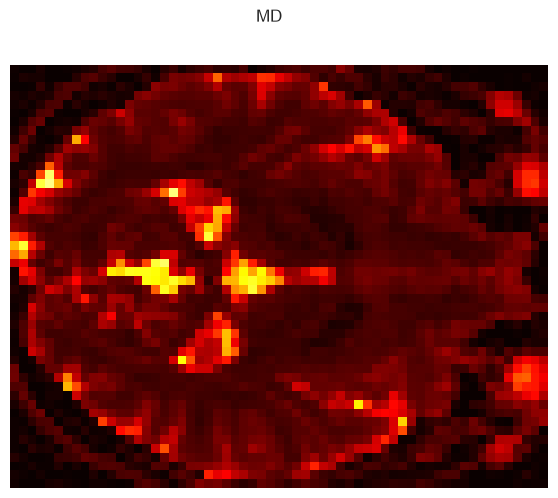

In [116]:
Helpers.Plot_parameter_map(MD[:,:,24],DTIModel,'MD',data_range = [0,5e-3])

(<Figure size 800x550 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

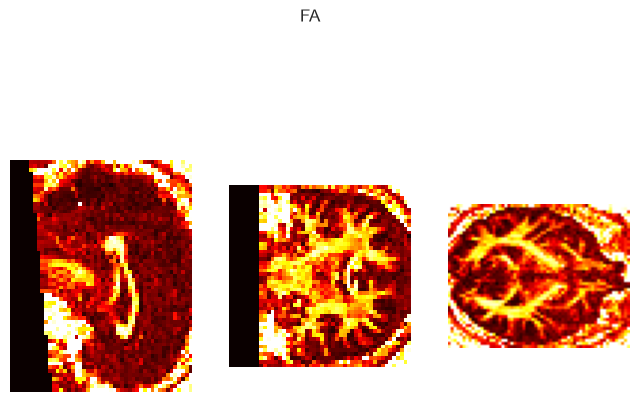

In [117]:
Helpers.Plot_parameter_map(FA,DTIModel,'FA',data_range = [0,1])

There is even a useful little widge that lets you scroll through the parameter:

In [118]:
Helpers.Widget_parameter_map(FA,DTIModel,'FA',data_range=[0,1],view='sag')

[0, 1]


Now lets do a stick and ball model:

In [119]:
SBModel = Model(gtab)
SBModel._add_compartment("DTI","Hindered")
SBModel._add_compartment("Sticks","Axons")
SBModel._add_compartment("Balls","Astrocytes")
SBModel._set_default_SNR(50)

In [120]:
Params,Signals = SBModel.sample_and_simulation(10_000,parallel=True,rng = np.random.default_rng(42))
Par,Obs,Names,Bounds = Helpers.Prep_data(Params,Signals,SBModel.parameter_list)

Simulating Astrocytes: : 3it [02:42, 54.20s/it]


As one of the fractions is redundant we will remove it (1-sum of the rest). We are removing: Hindered_f


In [121]:
SBNetwork = SBI.Train_Network_gpu(Par,Obs)
Result = SBI.Infer_from_volume(SBNetwork,data_norm,batch_size=32)

 Neural network successfully converged after 144 epochs.Network saved as 'saved_data/Network_10k_20260821_1152.pickle'
Starting inference....


100%|██████████████████████████████████████| 4392/4392 [05:07<00:00, 14.28it/s]


Reshaping result
Saving...


Given that we removed one of the fractions for the training, we can add it back so we have a complete picture of the model parameters. Keep in mind that Prep_data also removed this from the name space, so we need to add that back as well.

In [122]:
Result_aug,Names = Helpers.Add_back_fraction(Result,Names,SBModel)

Lets do some more plotting!

(<Figure size 800x550 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

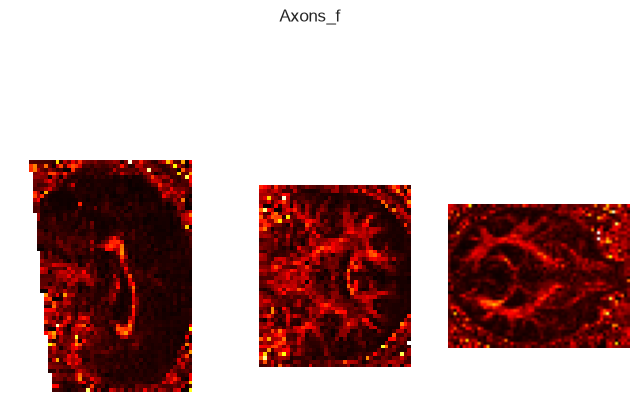

In [123]:
Helpers.Plot_parameter_map(Result_aug,SBModel,'Axons_f',data_range = [0,1])

We can also plot all parameters all at once. Either in all three axis:

Figure saved to 'saved_data/Hindered_f_20260821_1157.pdf'


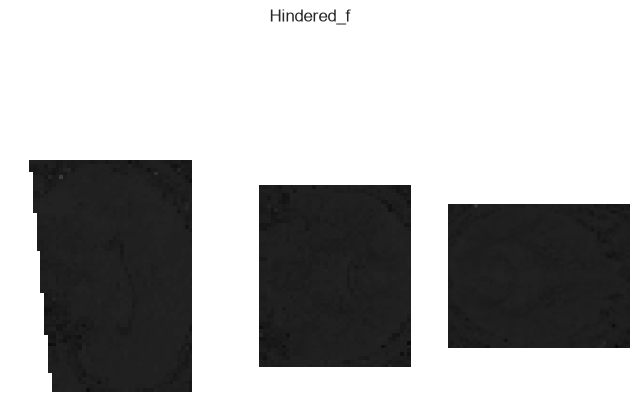

Figure saved to 'saved_data/Axons_f_20260821_1157.pdf'


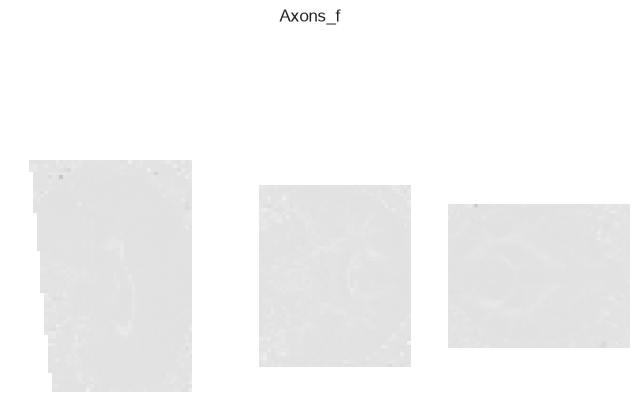

Figure saved to 'saved_data/Astrocytes_f_20260821_1157.pdf'


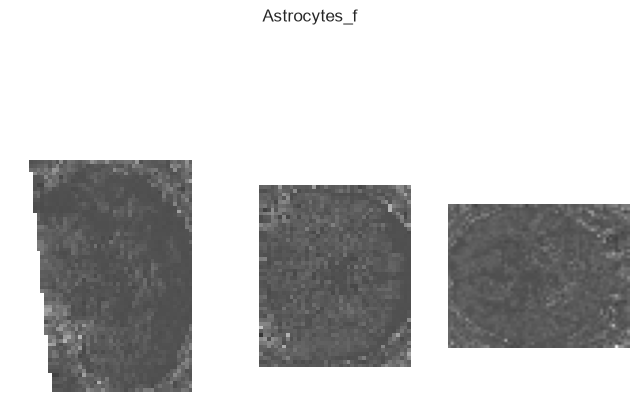

Figure saved to 'saved_data/Hindered_D_xx_20260821_1157.pdf'


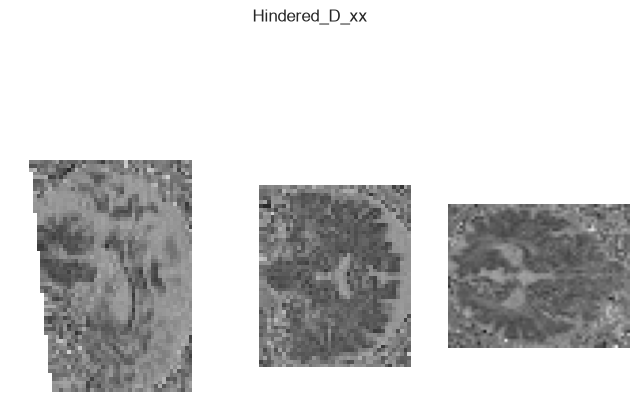

Figure saved to 'saved_data/Hindered_D_xy_20260821_1157.pdf'


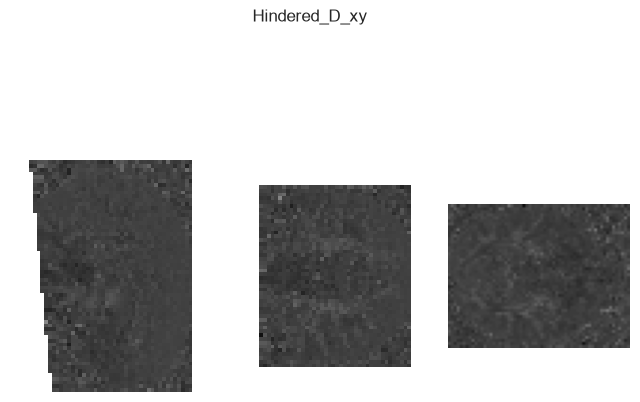

Figure saved to 'saved_data/Hindered_D_yy_20260821_1157.pdf'


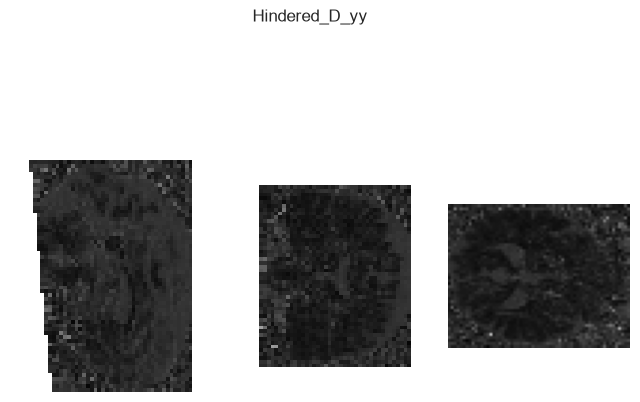

Figure saved to 'saved_data/Hindered_D_xz_20260821_1157.pdf'


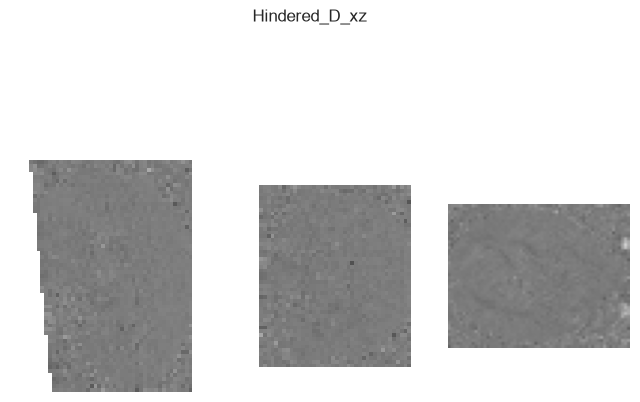

Figure saved to 'saved_data/Hindered_D_yz_20260821_1157.pdf'


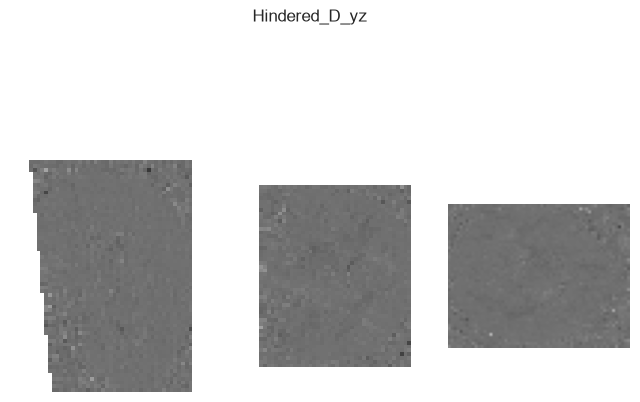

Figure saved to 'saved_data/Hindered_D_zz_20260821_1157.pdf'


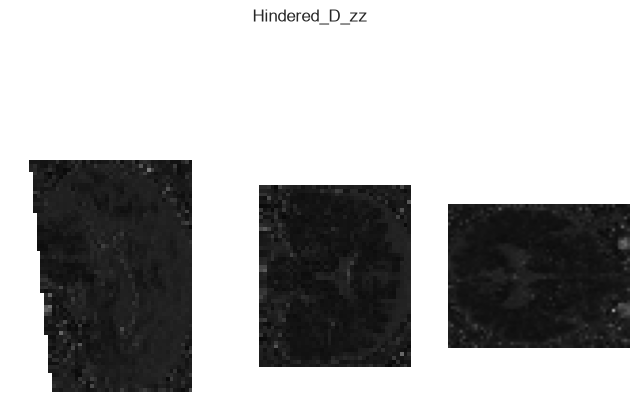

Figure saved to 'saved_data/Axons_theta_20260821_1157.pdf'


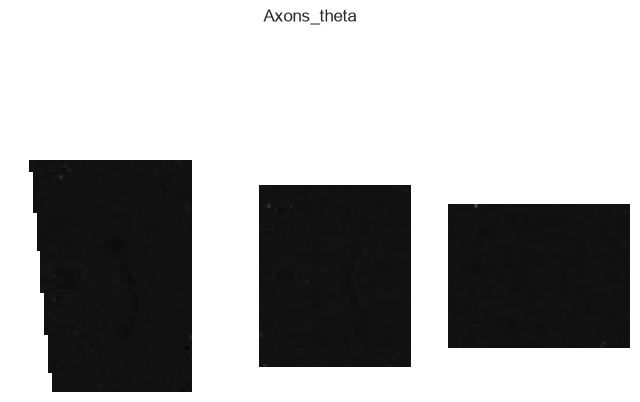

Figure saved to 'saved_data/Axons_phi_20260821_1157.pdf'


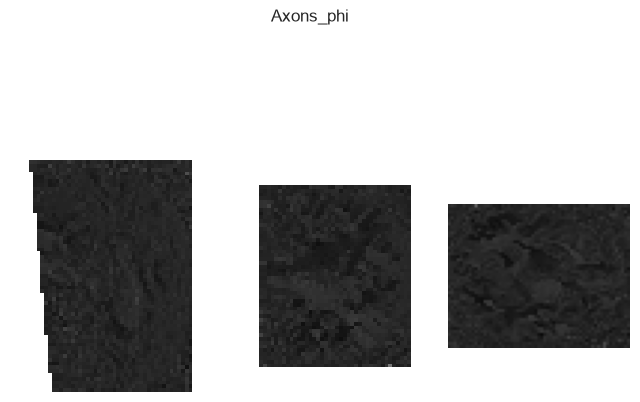

Figure saved to 'saved_data/Axons_D_par_20260821_1157.pdf'


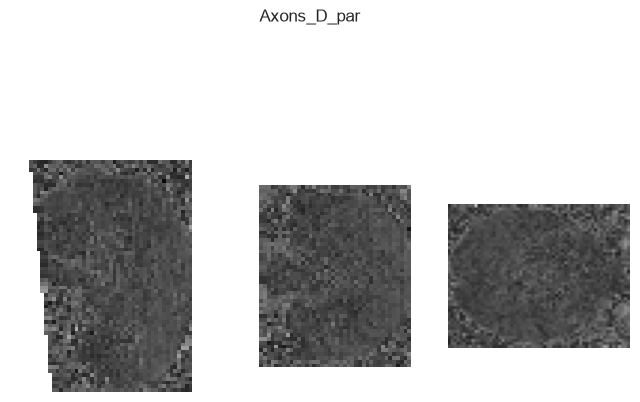

Figure saved to 'saved_data/Axons_D_perp_20260821_1157.pdf'


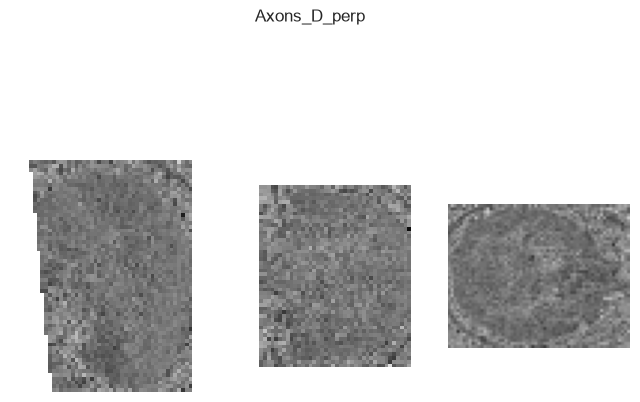

Figure saved to 'saved_data/Axons_size_20260821_1157.pdf'


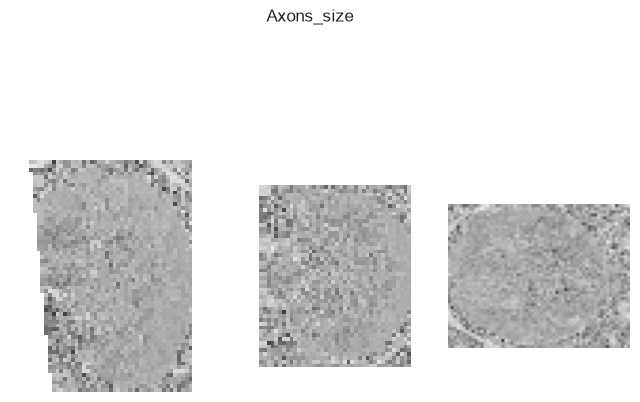

Figure saved to 'saved_data/Astrocytes_D_sph_20260821_1157.pdf'


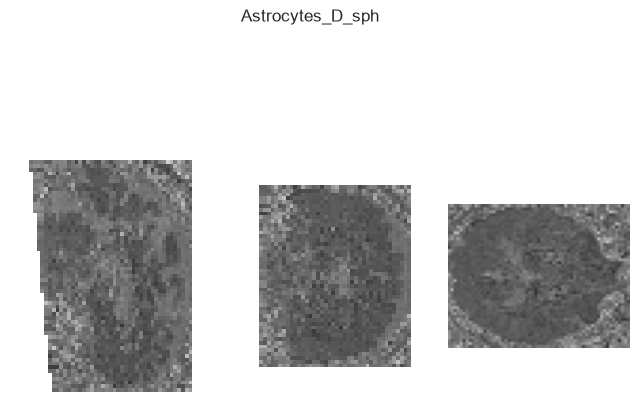

Figure saved to 'saved_data/Astrocytes_size_20260821_1157.pdf'


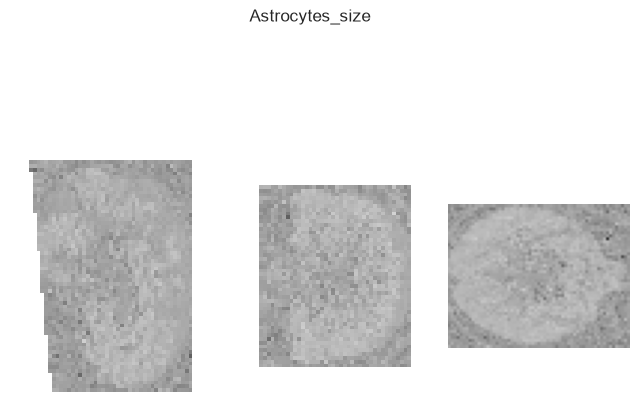

In [124]:
Helpers.Plot_parameter_maps(Result_aug,SBModel,Names,cmap='grey',save=True)

or just with one view:

Figure saved to 'saved_data/Hindered_f_20260821_1157.pdf'


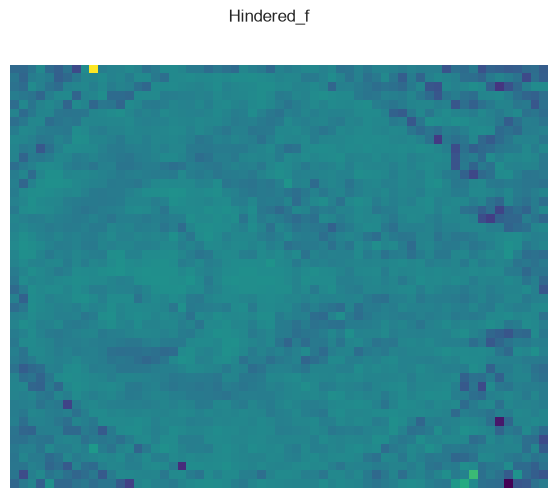

Figure saved to 'saved_data/Axons_f_20260821_1157.pdf'


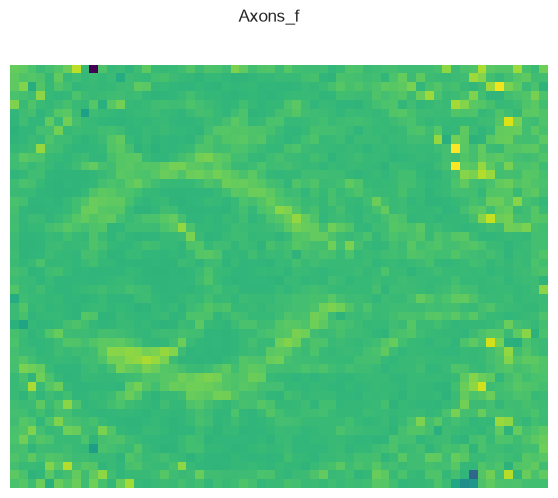

Figure saved to 'saved_data/Astrocytes_f_20260821_1157.pdf'


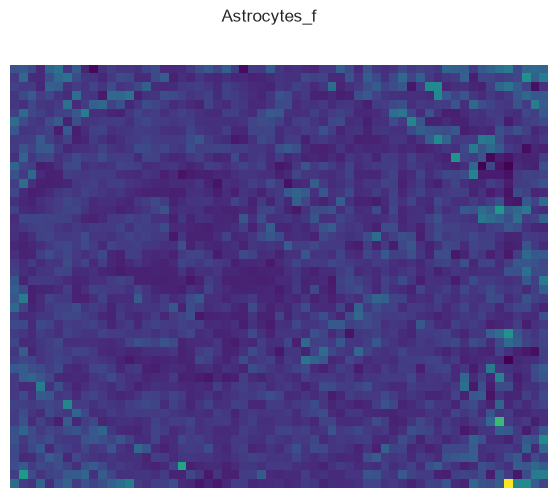

Figure saved to 'saved_data/Hindered_D_xx_20260821_1157.pdf'


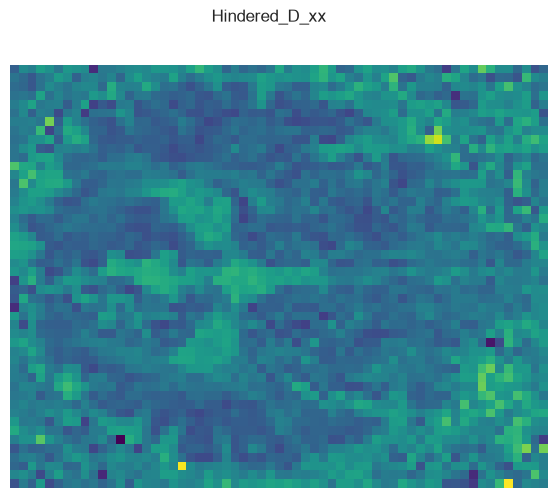

Figure saved to 'saved_data/Hindered_D_xy_20260821_1157.pdf'


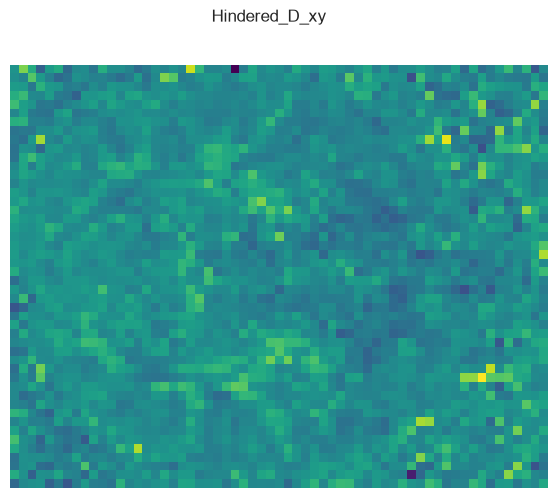

Figure saved to 'saved_data/Hindered_D_yy_20260821_1157.pdf'


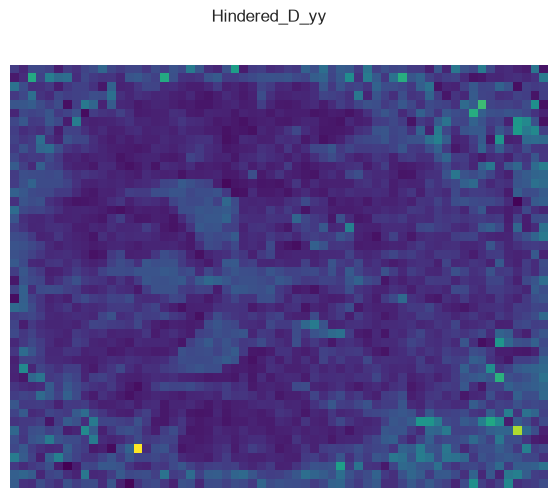

Figure saved to 'saved_data/Hindered_D_xz_20260821_1157.pdf'


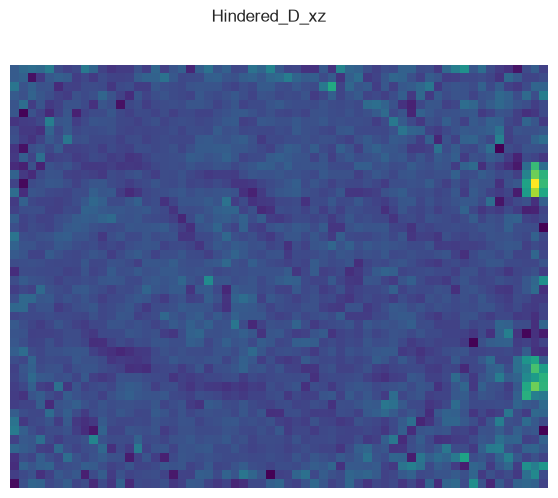

Figure saved to 'saved_data/Hindered_D_yz_20260821_1157.pdf'


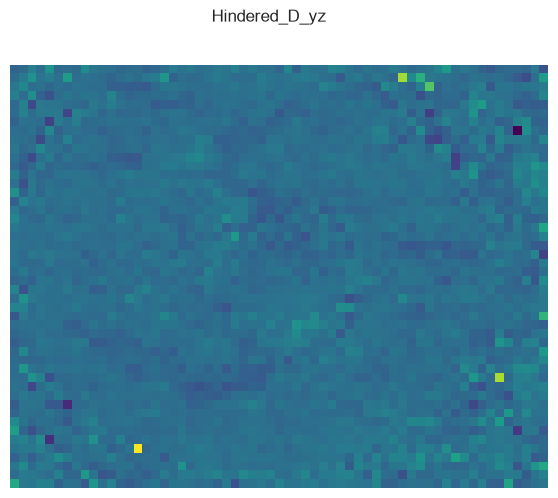

Figure saved to 'saved_data/Hindered_D_zz_20260821_1157.pdf'


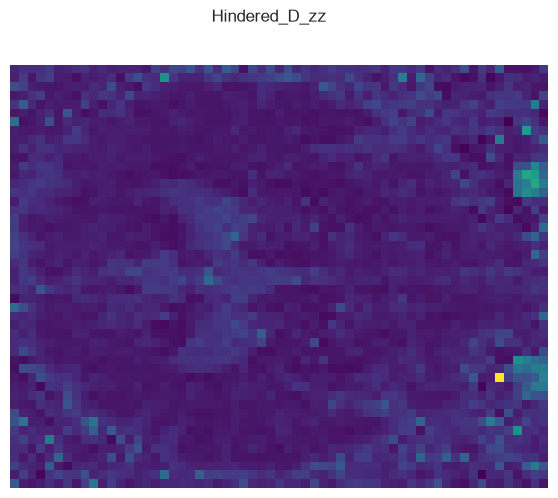

Figure saved to 'saved_data/Axons_theta_20260821_1157.pdf'


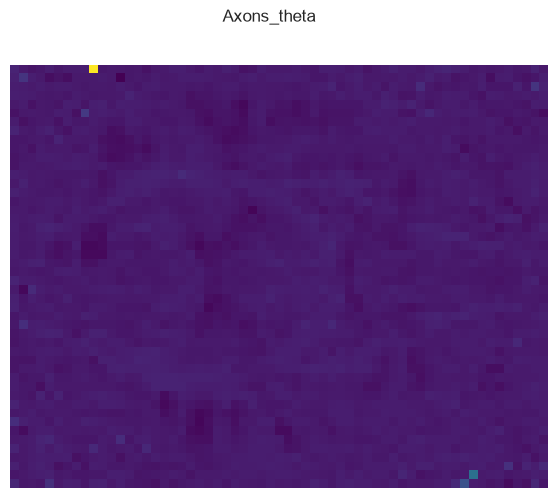

Figure saved to 'saved_data/Axons_phi_20260821_1157.pdf'


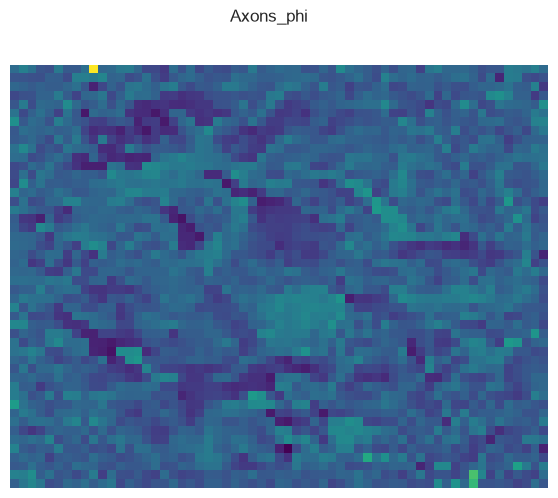

Figure saved to 'saved_data/Axons_D_par_20260821_1157.pdf'


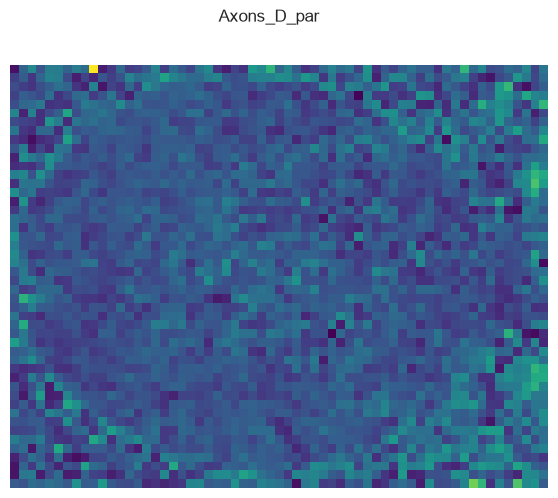

Figure saved to 'saved_data/Axons_D_perp_20260821_1157.pdf'


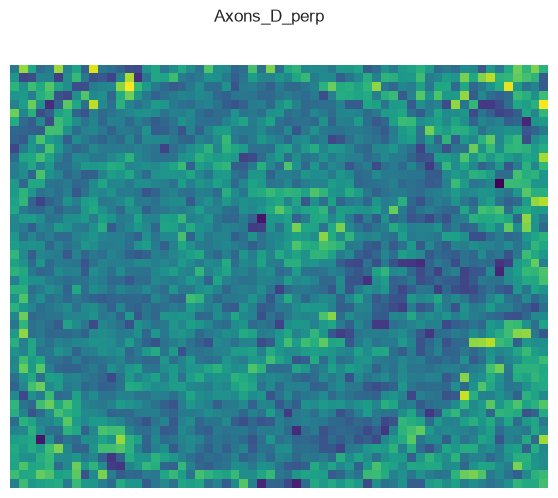

Figure saved to 'saved_data/Axons_size_20260821_1157.pdf'


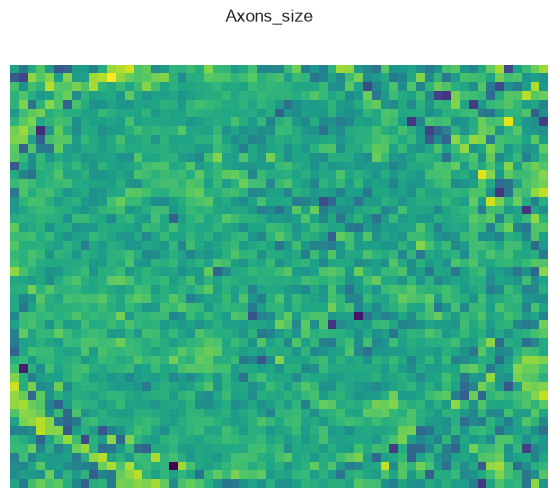

Figure saved to 'saved_data/Astrocytes_D_sph_20260821_1157.pdf'


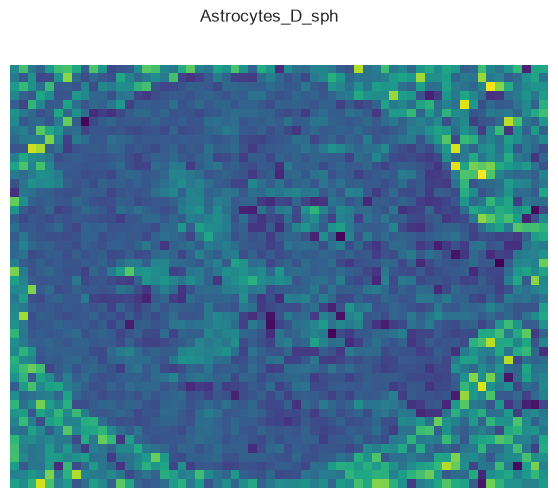

Figure saved to 'saved_data/Astrocytes_size_20260821_1157.pdf'


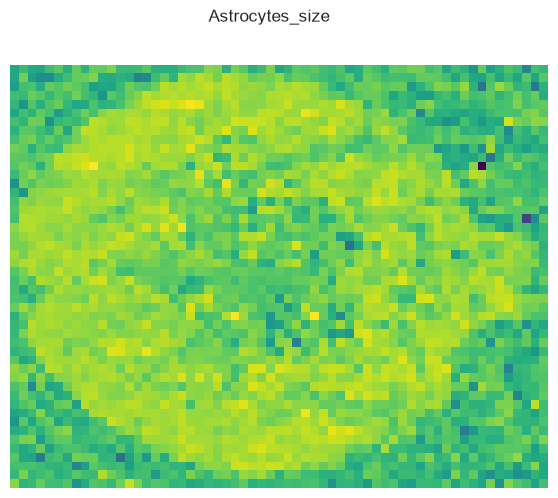

In [125]:
Helpers.Plot_parameter_maps(Result_aug[:,:,24],SBModel,Names,cmap='viridis',save=True)

Or we can use the widget again:

In [126]:
Helpers.Widget_parameter_map(Result_aug,SBModel,'Axons_f',data_range=[0,1])

[0, 1]


In [127]:
Helpers.Widget_parameter_map(Result_aug,SBModel,'Axons_f',data_range=[0,1],view='sag')

[0, 1]


# Validation

In [128]:
import Validation

This package also includes a Validation suite to test some of the parameters for the SBI inference and training. At this point, we only have this validation for posterior samples (ParameterEval_PS) and number of training samples (ParameterEval_TS). But future editions might include more parameter validation

In [129]:
DTIModel = Model(gtabSim)
DTIModel._add_compartment("DTI","Hindered") # The first "DTI" is what kind of model we want and "Hindered" is the name we give it
DTIModel._set_default_SNR(30)

In [133]:
help(Validation.ParameterEval_TS)

Help on function ParameterEval_TS in module Validation:

ParameterEval_TS(
    Model,
    validation_snr,
    k_fold=5,
    max_samples=100000,
    test_samples=10000,
    posterior_samples=500,
    fidelity=5,
    maximum_training_epochs=100
)
    Evaluate how the performance of a simulation-based inference (SBI) model
    changes as a function of the number of training samples.

    The function trains the SBI network using progressively larger training
    datasets, evaluates each trained network on a shared test set, and repeats
    the procedure across multiple folds. Performance metrics are collected for
    each training-set size and plotted at the end of the study.

    Parameters
    ----------
    Model : object
        Model used to generate parameters and simulated observations. It must
        provide a ``sample_and_simulation`` method and a ``parameter_list``
        attribute.

    validation_snr : float or array-like
        Signal-to-noise ratio (SNR) used when generat

~~~~~~~~~~~~~~~~~~~~
We will perform a study on the number of posterior samples we might need


Simulating Hindered: : 1it [00:00,  2.29it/s]


30


Simulating Hindered: : 1it [00:00,  2.21it/s]


 Neural network successfully converged after 165 epochs.

Fold Number:: 100%|██████████████████████████████| 5/5 [05:46<00:00, 69.35s/it]


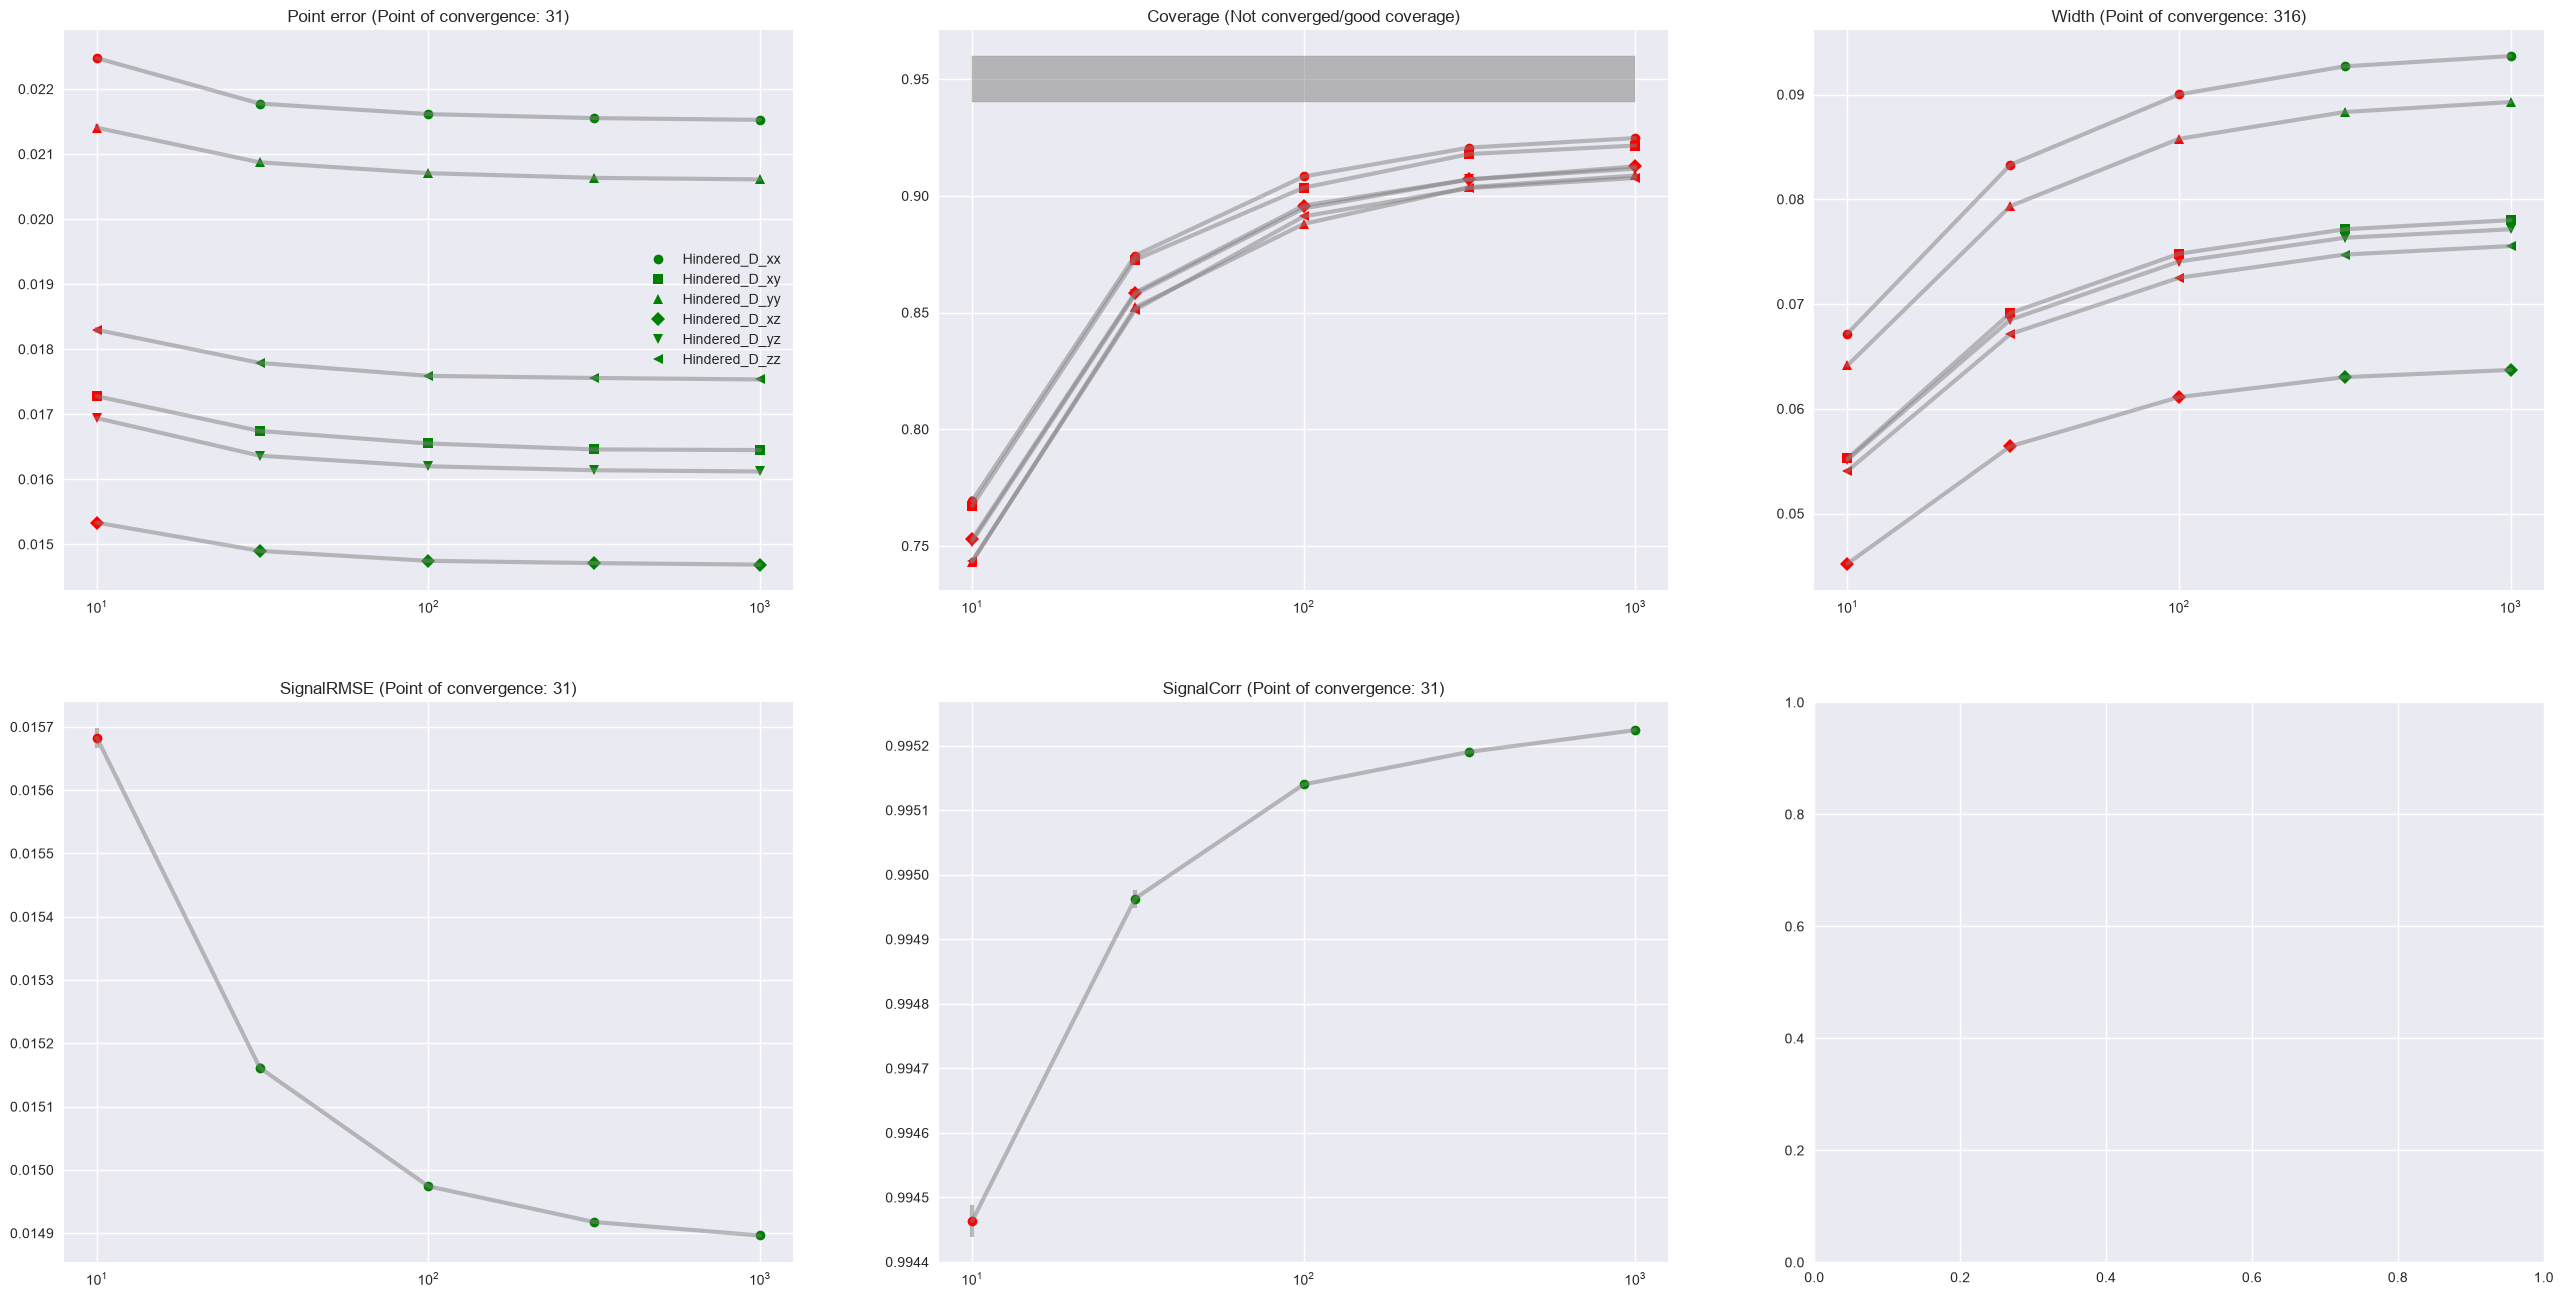

In [136]:
X = Validation.ParameterEval_PS(DTIModel,30,fidelity = 5)

Here we do a brief explanation of the figure that comes out of one of these parameter validations. 
- Point Error convergence (Top left): Using the mean of the distribution as the estimate of that parameter, we can compare this to the real ground trutch and see how it changes as we add more posterior samples.
- 95% Coverage (Top middle): A way to see if the posterior is well defined. Basically, it says if we sample from the posterior, the true value should fall within the 95% interval 95% of the time. Therefore, we have the gray area, all the points hshould ideally lie wihin it.
- Width (Top right): How broad is the 95% of the posterior as a fraction of the respective full parameter space - the smaller the better obviously. Important that this is checked with the coverage
- Signal RMSE (Bottom left): This shows the error of the reconstructed siganl  versus the true clean signal - idea of magnitude.
- Signal Corr (Bottom middle): This shows the correlation of the reconstructed siganl with the true clean signal - idea of directionality.

The code will try and tell you if things have "converged" - but this is heuristic at best. By marking points as green if, for example, the change between points is small enough or we are within the 95% coverage, we try to give an idea of which parameter you should choose. However, importantly I would not rely on this too much and instead look at directky.

~~~~~~~~~~~~~~~~~~~~
We will perform a study on the number of training samples we might need


Simulating Hindered: : 1it [00:03,  3.21s/it]


Fold Number::   0%|                                      | 0/5 [00:00<?, ?it/s]

Simulating Hindered: : 1it [00:05,  5.57s/it]


 Training neural network. Epochs trained: 101

 Training neural network. Epochs trained: 101

Fold Number::  20%|█████▊                       | 1/5 [04:59<19:56, 299.11s/it]

...

 Training neural network. Epochs trained: 101

 Training neural network. Epochs trained: 101

Fold Number::  60%|█████████████████▍           | 3/5 [14:47<09:49, 294.91s/it]

Simulating Hindered: : 1it [00:04,  4.13s/it]


 Training neural network. Epochs trained: 101

 Training neural network. Epochs trained: 101

Fold Number::  80%|███████████████████████▏     | 4/5 [19:38<04:53, 293.42s/it]

Simulating Hindered: : 1it [00:03,  3.79s/it]


 Training neural network. Epochs trained: 101

 Training neural network. Epochs trained: 101

Fold Number:: 100%|█████████████████████████████| 5/5 [24:31<00:00, 294.34s/it]


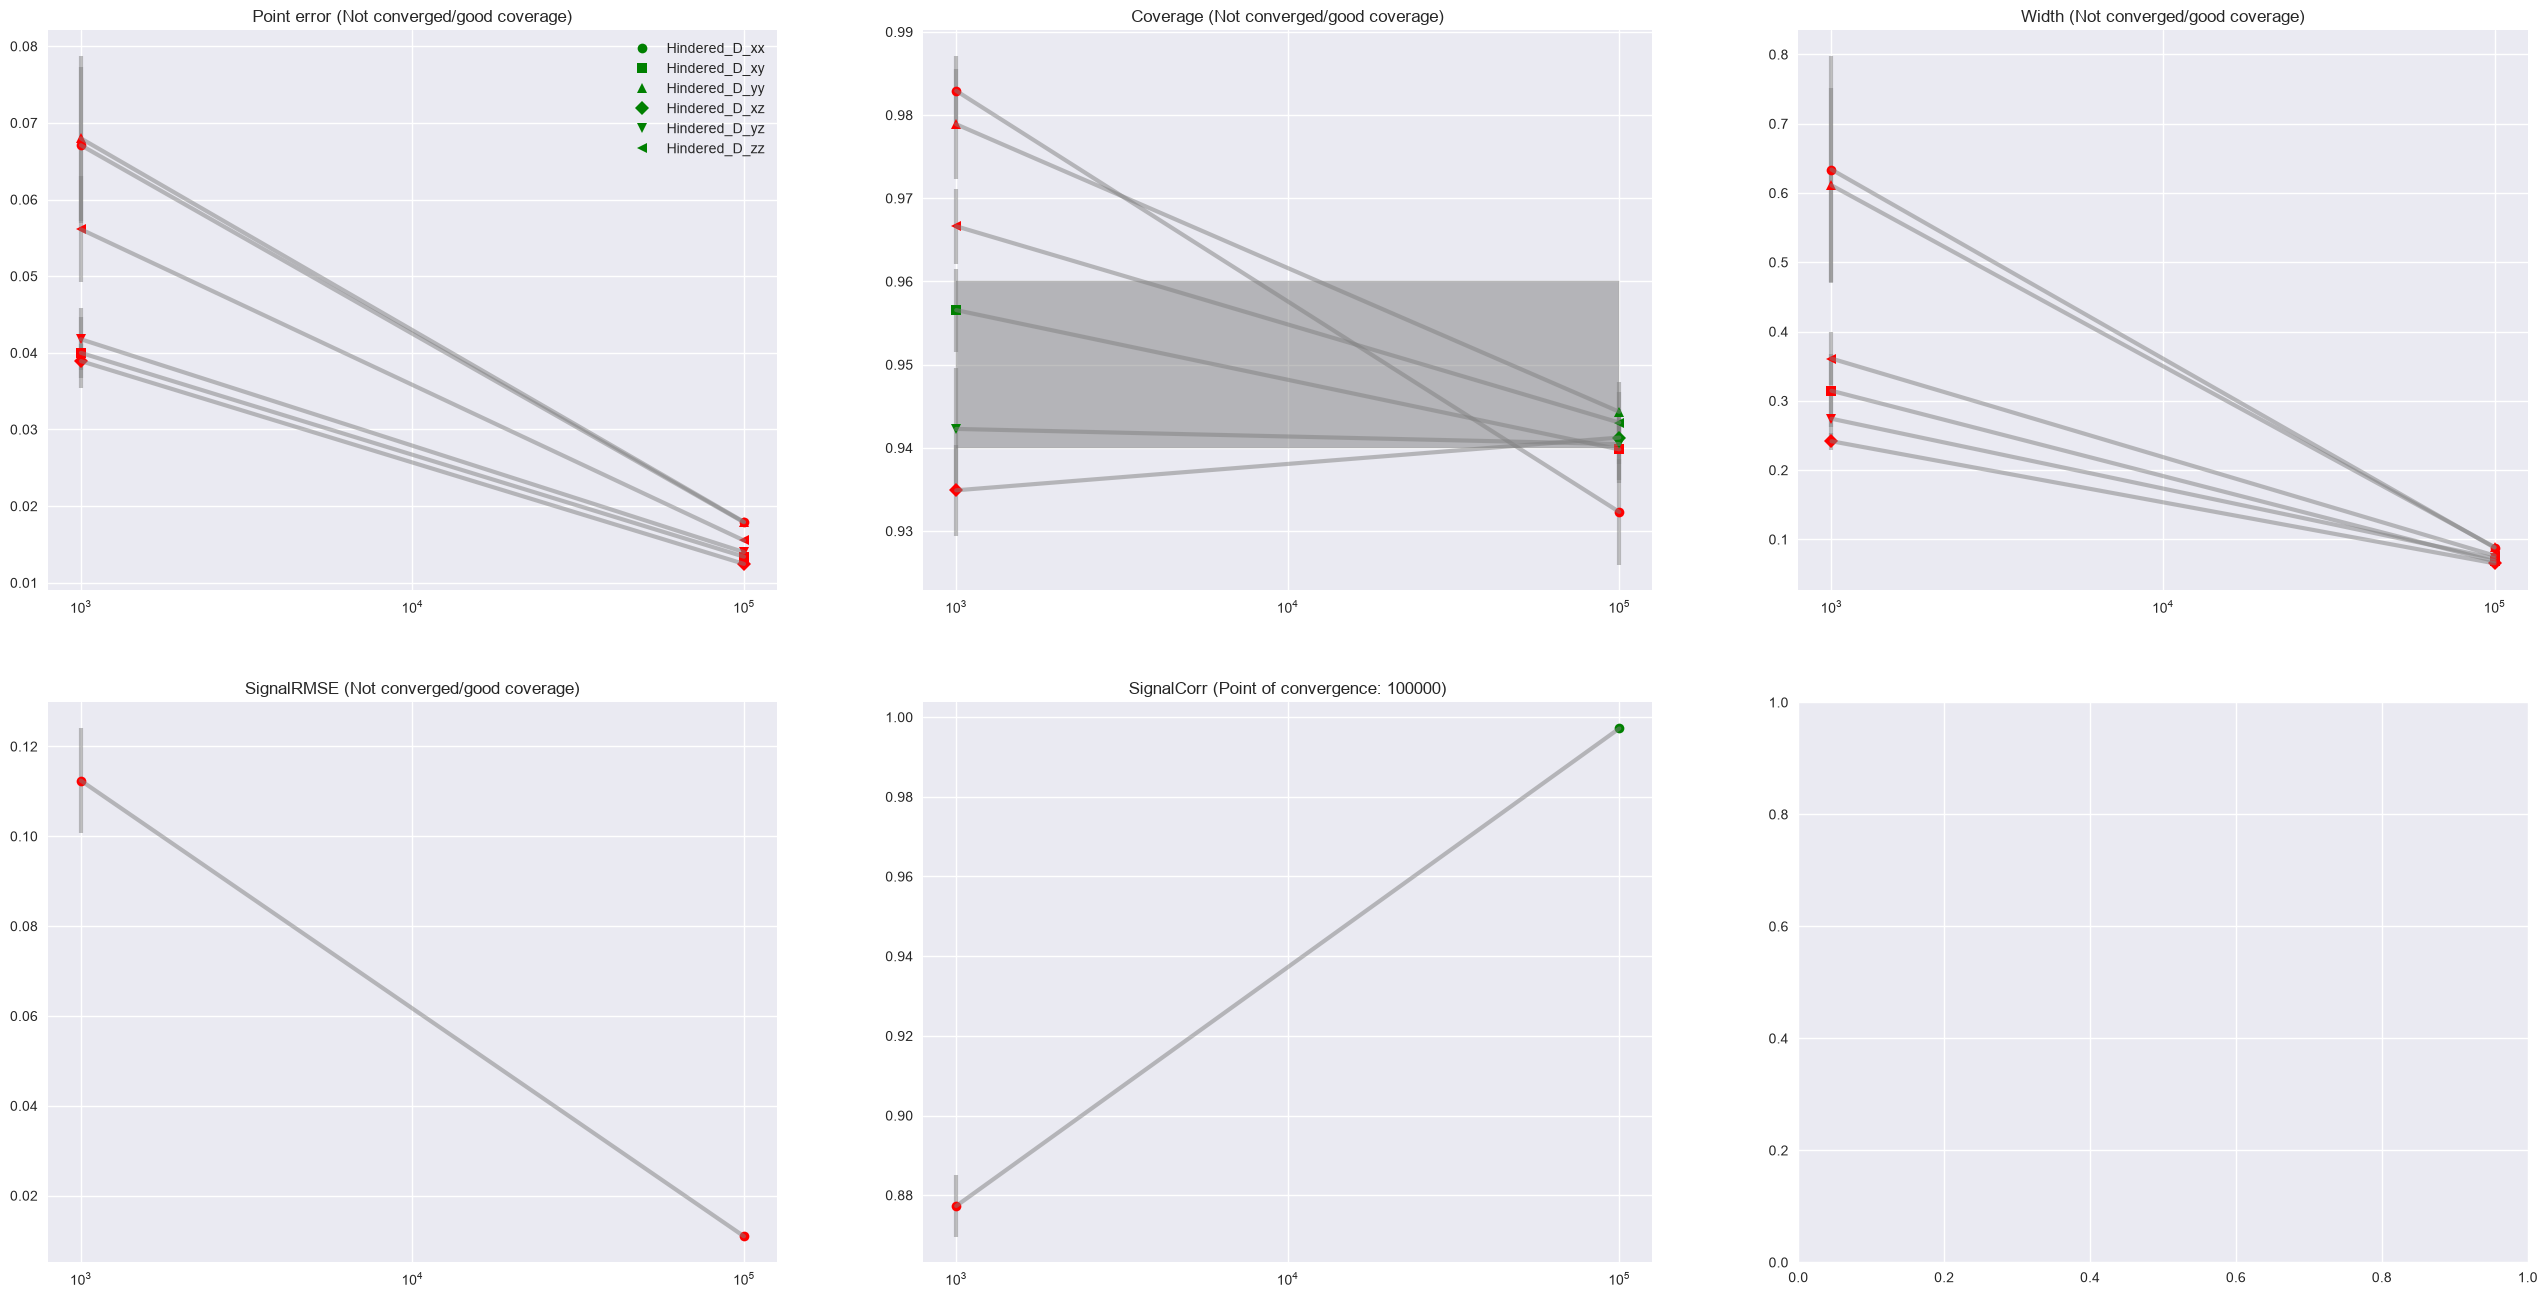

In [138]:
X = Validation.ParameterEval_TS(DTIModel,30,fidelity = 2)